In [1]:

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



# Q4 Results Analysis

This section analyzes the results produced in **Q4 – Training Set Size Analysis**.

The goal is to investigate how the amount of available training data affects fraud-detection performance and determine the point at which additional data provides diminishing returns.

Based on the conclusions from Questions 1–3, **Random Forest** was selected as the primary model and evaluated under different training-set sizes.

The analysis focuses on:

1. Classification performance.
2. Effect of SMOTE-Tomek balancing.
3. Feature-importance stability.
4. SHAP stability.
5. Saturation point detection.

---



## Load Experiment Results

Load the evaluation results and feature-analysis files generated during Q4.


In [2]:

current_path = Path.cwd()

while current_path.name != "MachineLearningProject":
    current_path = current_path.parent

PROJECT_ROOT = current_path

q4_results = pd.read_csv(
    PROJECT_ROOT / "out" / "Q4_results.csv"
)

q4_features = pd.read_csv(
    PROJECT_ROOT / "out" / "Q4_features.csv"
)

print(f"Results rows: {len(q4_results)}")
print(f"Feature rows: {len(q4_features)}")

q4_results.head()


Results rows: 38
Feature rows: 19


,train_size,train_samples,balancing,threshold_mode,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
0,Default,227845,NaN,default,0.999596,0.941176,0.816327,0.874317,0.963027,0.873391,56859,5,18,80
1,Default,227845,NaN,recall,0.001720,0.001720,1.000000,0.003435,0.963027,0.873391,0,56864,0,98
2,Default,453636,SMOTE_Tomek,default,0.999456,0.831683,0.857143,0.844221,0.969253,0.872876,56847,17,14,84
3,Default,453636,SMOTE_Tomek,recall,0.001720,0.001720,1.000000,0.003435,0.969253,0.872876,0,56864,0,98
4,1%,2278,NaN,default,0.999017,0.808824,0.561224,0.662651,0.937465,0.683931,56851,13,43,55



## Dataset Overview

Inspect the structure of the generated experiment results before performing any analysis.


In [3]:

q4_results.info()

q4_results.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   train_size       38 non-null     object 
 1   train_samples    38 non-null     int64  
 2   balancing        18 non-null     object 
 3   threshold_mode   38 non-null     object 
 4   accuracy         38 non-null     float64
 5   precision        38 non-null     float64
 6   recall           38 non-null     float64
 7   f1               38 non-null     float64
 8   roc_auc          38 non-null     float64
 9   pr_auc           38 non-null     float64
 10  true_negatives   38 non-null     int64  
 11  false_positives  38 non-null     int64  
 12  false_negatives  38 non-null     int64  
 13  true_positives   38 non-null     int64  
dtypes: float64(6), int64(5), object(3)
memory usage: 4.3+ KB


,train_samples,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,145823.315789,0.500545,0.428794,0.882116,0.404014,0.953904,0.808771,28425.605263,28438.394737,11.552632,86.447368
std,142218.705815,0.505521,0.434389,0.134553,0.408285,0.010919,0.067571,28807.174327,28807.174327,13.186187,13.186187
min,2278.000000,0.001720,0.001720,0.540816,0.003435,0.936415,0.667346,0.000000,4.000000,0.000000,53.000000
25%,21681.500000,0.001720,0.001720,0.795918,0.003435,0.943862,0.776730,0.000000,13.000000,0.000000,78.000000
50%,91138.000000,0.500360,0.396900,0.928571,0.326871,0.955076,0.845595,28421.500000,28442.500000,7.000000,91.000000
75%,222148.750000,0.999377,0.836046,1.000000,0.815130,0.962107,0.861284,56851.000000,56864.000000,20.000000,98.000000
max,453636.000000,0.999596,0.951220,1.000000,0.874317,0.970369,0.873391,56860.000000,56864.000000,45.000000,98.000000



# Training Size Performance Analysis

The purpose of this section is to understand how performance changes as additional training data becomes available.

Because fraud detection suffers from severe class imbalance, we focus primarily on:

- Recall
- Precision
- F1 Score
- PR-AUC
- ROC-AUC

A saturation point is expected once adding more data yields only marginal improvements.



## Average Performance By Training Size

Aggregate all configurations by training size to observe the overall trend.


In [4]:

metrics = [
    "precision",
    "recall",
    "f1",
    "pr_auc",
    "roc_auc"
]

performance_summary = (
    q4_results
    .groupby(
        ["train_size", "balancing"]
    )[metrics]
    .mean()
    .reset_index()
)

performance_summary


,train_size,balancing,precision,recall,f1,pr_auc,roc_auc
0,10%,SMOTE_Tomek,0.420215,0.897959,0.410094,0.700496,0.950870
1,2%,SMOTE_Tomek,0.419610,0.841837,0.378122,0.774662,0.936415
2,20%,SMOTE_Tomek,0.403921,0.903061,0.404779,0.796292,0.965369
3,40%,SMOTE_Tomek,0.408077,0.903061,0.406846,0.828664,0.970369
4,5%,SMOTE_Tomek,0.430272,0.872449,0.400625,0.792702,0.956508
5,60%,SMOTE_Tomek,0.408627,0.928571,0.419628,0.858569,0.955076
6,80%,SMOTE_Tomek,0.410860,0.918367,0.415859,0.858206,0.959348
7,90%,SMOTE_Tomek,0.396900,0.908163,0.403728,0.869090,0.969670
8,Default,SMOTE_Tomek,0.416702,0.928571,0.423828,0.872876,0.969253



## Recall Growth Curve

Recall is the most important metric in fraud detection since false negatives represent missed fraud cases.

The following graph shows how recall evolves as additional training data becomes available.


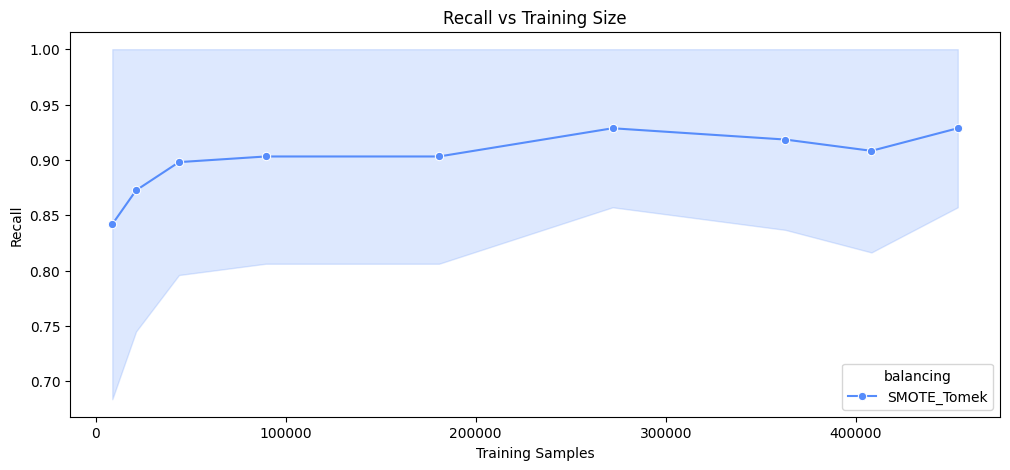

In [5]:

plt.figure(figsize=(12,5))

sns.lineplot(
    data=q4_results,
    x="train_samples",
    y="recall",
    hue="balancing",
    marker="o"
)

plt.title("Recall vs Training Size")
plt.xlabel("Training Samples")
plt.ylabel("Recall")

plt.show()



### Discussion

Expected observations:

- Small datasets usually produce unstable recall.
- Recall tends to improve rapidly in early stages.
- The curve eventually flattens.
- The flattening point indicates performance saturation.



## Precision Analysis


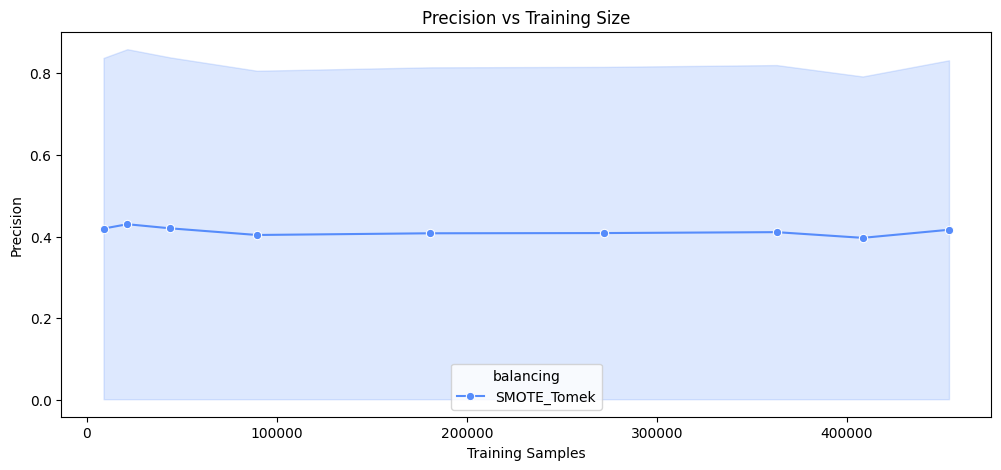

In [6]:

plt.figure(figsize=(12,5))

sns.lineplot(
    data=q4_results,
    x="train_samples",
    y="precision",
    hue="balancing",
    marker="o"
)

plt.title("Precision vs Training Size")
plt.xlabel("Training Samples")
plt.ylabel("Precision")

plt.show()



### Discussion

Precision indicates how many transactions predicted as fraud were actually fraudulent.

Increasing dataset size should reduce prediction noise and improve precision stability.



## F1 Score Analysis

F1-score combines precision and recall into a single metric.

This allows us to evaluate the overall fraud-detection quality while considering both false positives and false negatives.


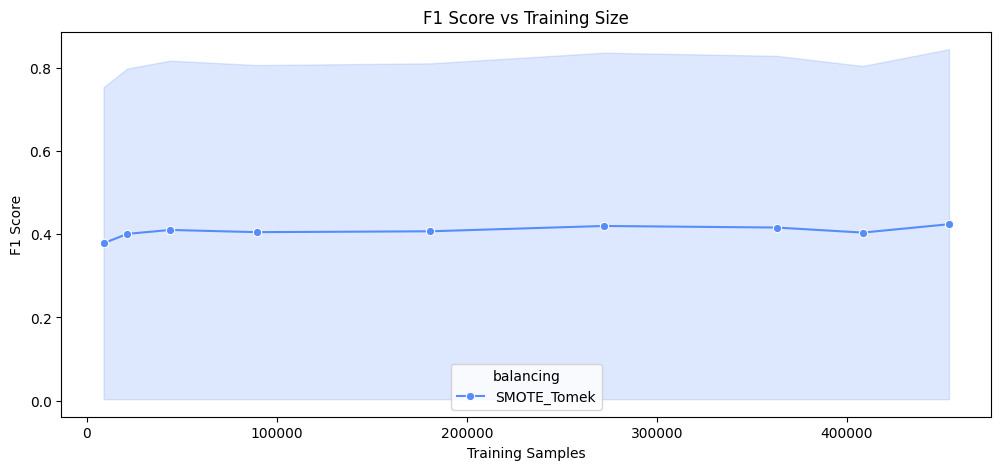

In [7]:

plt.figure(figsize=(12,5))

sns.lineplot(
    data=q4_results,
    x="train_samples",
    y="f1",
    hue="balancing",
    marker="o"
)

plt.title("F1 Score vs Training Size")
plt.xlabel("Training Samples")
plt.ylabel("F1 Score")

plt.show()



## PR-AUC Analysis

Since fraud detection is highly imbalanced, PR-AUC provides a more informative evaluation than Accuracy.

PR-AUC focuses specifically on minority-class performance.


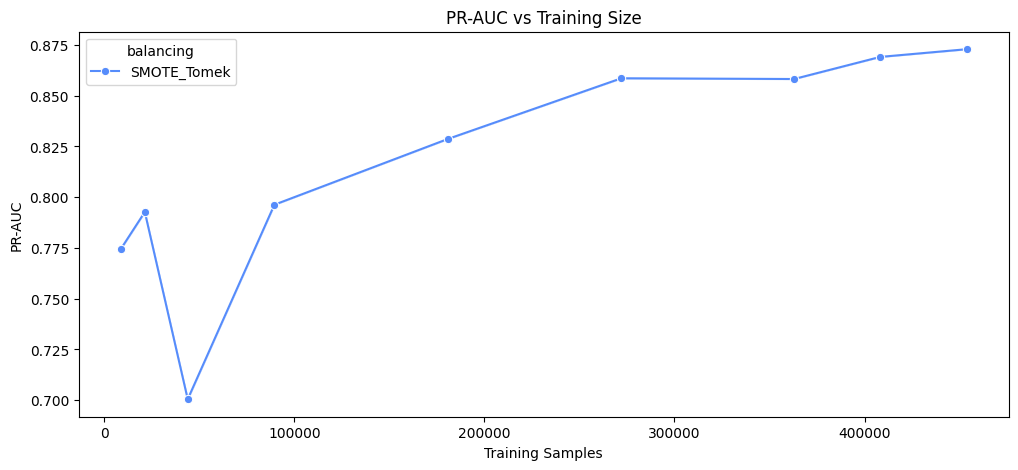

In [8]:

plt.figure(figsize=(12,5))

sns.lineplot(
    data=q4_results,
    x="train_samples",
    y="pr_auc",
    hue="balancing",
    marker="o"
)

plt.title("PR-AUC vs Training Size")
plt.xlabel("Training Samples")
plt.ylabel("PR-AUC")

plt.show()



# Effect of SMOTE-Tomek

This section examines whether balancing remains beneficial as more data becomes available.

The primary question:

Does balancing improve fraud-detection performance once large amounts of training data are available?


In [9]:

best_configs = (
    q4_results
    .sort_values(
        ["f1", "recall"],
        ascending=False
    )
)

best_configs.head(20)


,train_size,train_samples,balancing,threshold_mode,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
0,Default,227845,NaN,default,0.999596,0.941176,0.816327,0.874317,0.963027,0.873391,56859,5,18,80
26,60%,136707,NaN,default,0.999579,0.951220,0.795918,0.866667,0.947699,0.857325,56860,4,20,78
30,80%,182276,NaN,default,0.999579,0.951220,0.795918,0.866667,0.952655,0.863550,56860,4,20,78
34,90%,205060,NaN,default,0.999561,0.939759,0.795918,0.861878,0.958050,0.862189,56859,5,20,78
2,Default,453636,SMOTE_Tomek,default,0.999456,0.831683,0.857143,0.844221,0.969253,0.872876,56847,17,14,84
22,40%,91138,NaN,default,0.999473,0.886364,0.795918,0.838710,0.952698,0.850050,56854,10,20,78
28,60%,272038,SMOTE_Tomek,default,0.999421,0.815534,0.857143,0.835821,0.955076,0.858569,56845,19,14,84
32,80%,362916,SMOTE_Tomek,default,0.999403,0.820000,0.836735,0.828283,0.959348,0.858206,56846,18,16,82
18,20%,45569,NaN,default,0.999438,0.875000,0.785714,0.827957,0.942583,0.845595,56853,11,21,77
16,10%,43888,SMOTE_Tomek,default,0.999386,0.838710,0.795918,0.816754,0.950870,0.700496,56849,15,20,78



## Balancing Discussion

Things to examine:

- Does SMOTE-Tomek consistently improve recall?
- Does it reduce precision?
- Is balancing still useful at large training sizes?
- Does its benefit decrease as more real fraud samples become available?



# Feature Importance Stability Analysis

An effective fraud-detection system should identify approximately the same important features regardless of training-set size.

We now examine how stable the feature rankings remain throughout the experiment.
`


In [10]:
q4_features.head()

,train_size,balancing,top_features,shap_stats
0,Default,NaN,"[{'feature': 'V17', 'importance': 0.1703246439...",{'shap_importance': V17 0.002883\nV14 0....
1,Default,SMOTE_Tomek,"[{'feature': 'V14', 'importance': 0.2109446250...",{'shap_importance': V14 0.086936\nV4 0....
2,1%,NaN,"[{'feature': 'V14', 'importance': 0.1996598504...",{'shap_importance': V10 0.001099\nV17 0....
3,2%,NaN,"[{'feature': 'V17', 'importance': 0.1467757927...",{'shap_importance': V17 0.001220\nV10 0....
4,2%,SMOTE_Tomek,"[{'feature': 'V14', 'importance': 0.2190998571...",{'shap_importance': V14 0.132932\nV10 0....


## Parse Feature Logs

In [11]:

import ast

q4_features["top_features"] = q4_features[
    "top_features"
].apply(ast.literal_eval)



## Most Frequent Top Features

Count how often each feature appears among the top-ranked features.


In [12]:

from collections import Counter

counter = Counter()

for feature_list in q4_features["top_features"]:

    for feature in feature_list:
        counter[
            feature["feature"]
        ] += 1

feature_stability = pd.DataFrame(
    counter.items(),
    columns=[
        "feature",
        "count"
    ]
)

feature_stability = feature_stability.sort_values(
    "count",
    ascending=False
)

feature_stability.head(15)


,feature,count
0,V17,19
1,V14,19
2,V12,19
3,V10,19
5,V11,19
7,V4,18
6,V9,16
4,V16,15
10,V3,14
9,V7,11


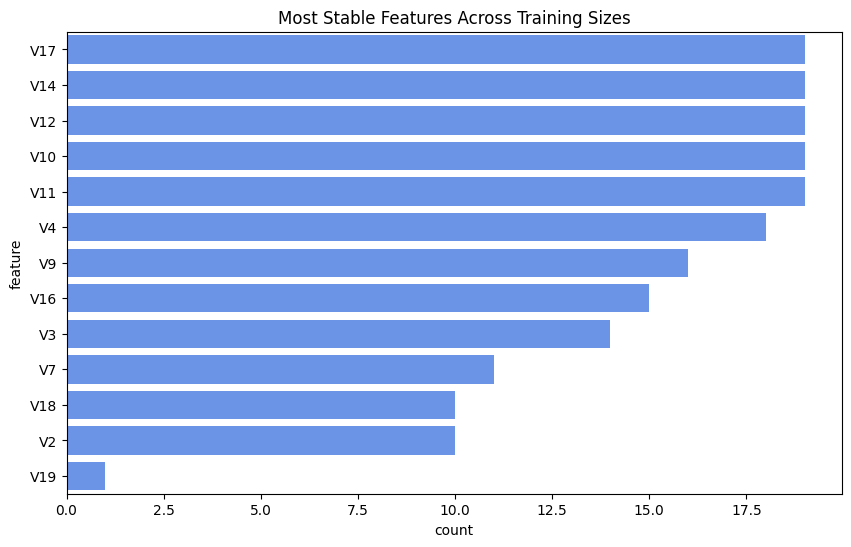

In [13]:

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_stability.head(15),
    x="count",
    y="feature"
)

plt.title(
    "Most Stable Features Across Training Sizes"
)

plt.show()



### Discussion

Features repeatedly appearing among the top-ranked predictors indicate robust fraud-related signals.

Stable rankings suggest that the model learns the same underlying fraud patterns regardless of available training data.



# SHAP Stability Analysis

SHAP explanations help determine whether the model continues to rely on the same decision signals as more training data becomes available.

Questions:

1. Are the same features dominant?
2. Do rankings converge?
3. Do new features emerge only at large training sizes?



# Saturation Point Detection

The primary goal of Q4 is identifying the point at which additional training data no longer produces meaningful improvements.


In [14]:

saturation_table = (
    q4_results
    .groupby("train_size")
    [
        [
            "recall",
            "f1",
            "pr_auc"
        ]
    ]
    .mean()
)

saturation_table


,recall,f1,pr_auc
train_size,,,
1%,0.780612,0.333043,0.683931
10%,0.869898,0.395172,0.741716
2%,0.806122,0.352496,0.721004
20%,0.897959,0.410237,0.820944
40%,0.900510,0.413959,0.839357
5%,0.872449,0.397408,0.760742
60%,0.913265,0.427339,0.857947
80%,0.908163,0.425455,0.860878
90%,0.903061,0.418192,0.865639



## Saturation Discussion

Look for:

- Stable recall.
- Stable F1.
- Stable PR-AUC.

The smallest training size after which improvements become marginal is considered the effective saturation point.



# Q4 Final Conclusions

From the generated results we aim to determine:

1. How performance changes as more training data becomes available.
2. Whether SMOTE-Tomek remains beneficial across dataset sizes.
3. The approximate saturation point.
4. Whether feature importance remains stable.
5. Whether the Random Forest model relies on consistent fraud indicators.

### Expected Conclusion Structure

- Performance improved significantly between small and medium datasets.
- Improvements became smaller at larger training sizes.
- SMOTE-Tomek provided the greatest benefit for small datasets.
- Feature rankings remained relatively stable.
- The model reached practical saturation around the identified training-size threshold.
